# Analysis of Stochastic Sampling Results for keff

In [1]:
import h5py
import tarfile
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats

In this section, we compare the impact of perturbing different **individual nuclear data components** on the effective multiplication factor (keff).

Four datasets are considered:

- **all** — all nuclear data components perturbed simultaneously
- **nubar** — only nubar(average neutrons per fission) perturbed
- **pfns** — only the prompt fission neutron spectrum (PFNS) perturbed
- **fiss_capt** — only fission and capture cross sections are perturbed (including correlations) 

The perturbed nuclear data files were generated on a different machine running `sandy` with the following commands:

**nubar**
```bash
python -m sandy.sampling U235.jeff40 --samples 100 --processes 10  --acer --temperatures 293.6 --mf 31
```

**pfns**
```bash
python -m sandy.sampling U235.jeff40 --samples 100 --processes 10  --acer --temperatures 293.6 --mf 35
```

**fiss_capt**
```bash
python -m sandy.sampling U235.jeff40 --samples 100 --processes 10  --acer --temperatures 293.6 --mf 33 --mt33 18 102
```

## 📥 Loading the Data

The following code loads the perturbed statepoint files.

Each row of each dataframe corresponds to one stochastic realization of perturbed cross sections.

In [2]:
keys = ["alldata", "nubar", "pfns", "fiss_capt"]

dfs = {}
for key in keys:
    folder = Path(f"u235_{key}")

    df_temp = {}
    for i in range(100):
        f = h5py.File(folder / f'statepoint.500_{i}.h5', 'r')
        df_temp[i] = f["k_combined"][:]
    df_temp = pd.DataFrame(df_temp, index=["KEFF", "DELTA_KEFF"]).T

    dfs[key] = df_temp

## 📊 Distribution of keff

Each subplot shows:

- Histogram of keff for that subset
- Mean value (red vertical line)
- ±1σ band (gray shaded region, in pcm)

This allows a direct visual comparison of how strongly each XS component contributes to the total uncertainty in keff.
Typically:

- The **alldata** case provides the baseline total propagated uncertainty
- The contribution of each subset should be smaller (within statistical noise)
- Each contribution carries the same statistical noise (determined by number of histories in openmc)
- If ony a few reactions are perturbed (e.g., fission and capture in **fiss_capt**), their correlations with other reactions are neglected.

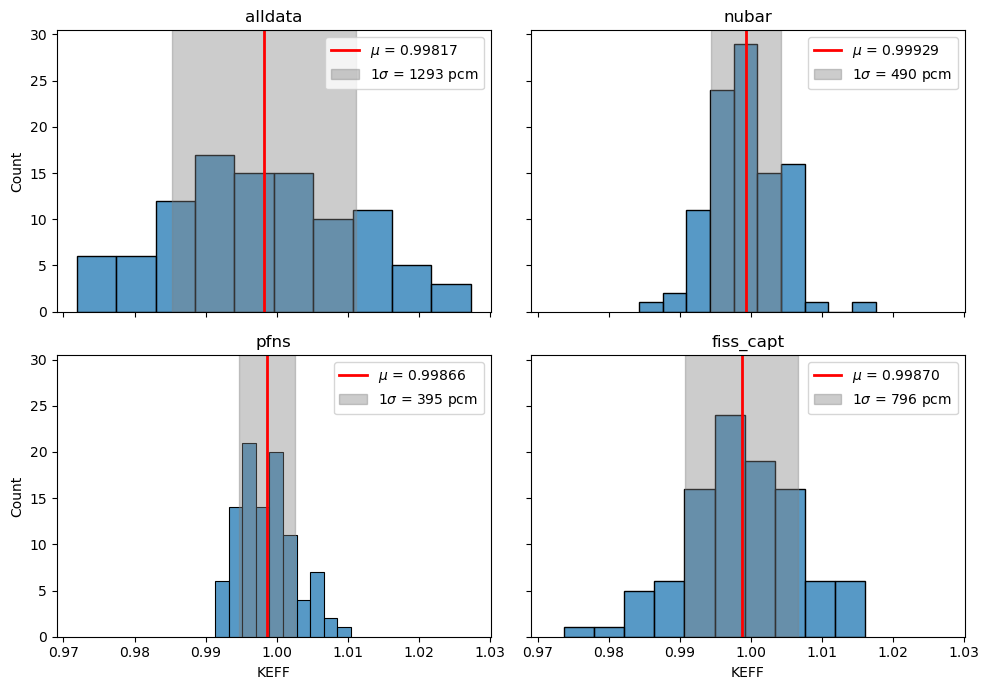

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

map_ax = {
    "alldata":       (0, 0),
    "nubar":     (0, 1),
    "pfns":      (1, 0),
    "fiss_capt": (1, 1),
}

for key in dfs:
    ax = axs[map_ax[key]]

    data = dfs[key]["KEFF"]
    
    sns.histplot(data=data, bins=10, ax=ax)
    
    loc = data.mean()
    scale = data.std()
    ax.axvline(loc, color="red", lw=2, label=rf"$\mu$ = {loc:.5f}")
    ax.axvspan(loc - scale, loc + scale, color="gray", alpha=.4, label=rf"1$\sigma$ = {scale * 1e5:.0f} pcm")
    
    ax.legend()
    ax.set(title=rf"{key}")

fig.tight_layout()

## 📈 KDE, Normal Fit, Q–Q Plot, and Normality Assessment

In this section, we examine the distribution of the sampled keff values using:

- Kernel Density Estimate (KDE)
- Normal distribution fit
- Q–Q plot
- Shapiro–Wilk normality test

These tools help determine whether the sampled keff values follow an approximately normal distribution (as expected when perturbations are small).

We can examine the distribution of the sampled keff for each subset. Just change the key below.

In [4]:
key = "fiss_capt"   # we can change this

ShapiroResult(statistic=np.float64(0.9860328445610429), pvalue=np.float64(0.3759331722143127))

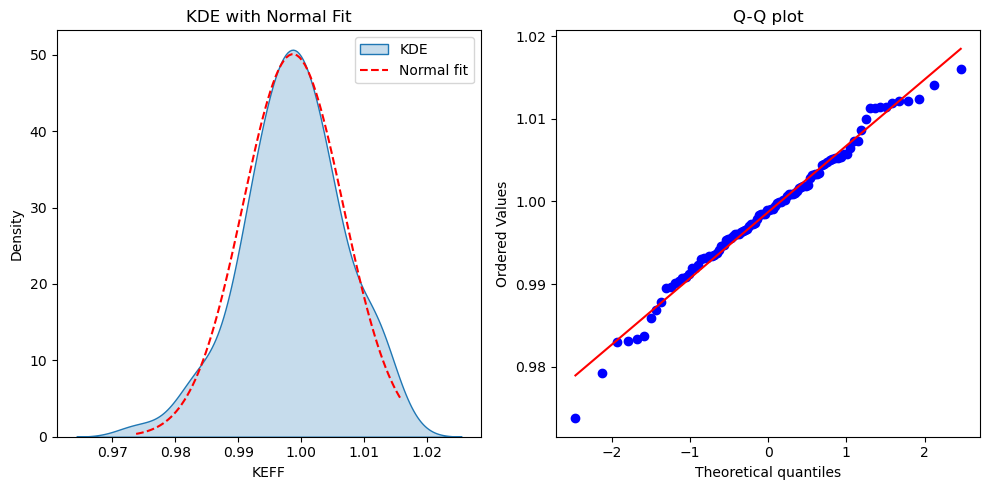

In [5]:
# data
data = dfs[key]["KEFF"]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot KDE
ax = axs[0]
sns.kdeplot(data, fill=True, label="KDE", ax=ax)

# Fit a normal distribution to the samples
mu, std = data.mean(), data.std()
xmin, xmax = data.min(), data.max()
x = np.linspace(xmin, xmax, 100)
ax.plot(x, stats.norm.pdf(x, mu, std), 'r--', label="Normal fit")

# Labels
ax.set(xlabel="KEFF", ylabel="Density", title="KDE with Normal Fit")
ax.legend()

# Q-Q plot
ax = axs[1]
stats.probplot(data, dist="norm", plot=ax)
ax.set(title="Q-Q plot")

fig.tight_layout()

stats.shapiro(data)

### KDE vs Normal Fit

- The KDE curve shows the empirical distribution of keff.
- The dashed red curve shows the best-fitting normal distribution.
- Good agreement suggests keff varies approximately normally due to stochastic XS perturbations.

---

### Q–Q Plot

- Points lying close to the diagonal line indicate normality.
- Systematic curvature implies skewness or heavy tails.

---

### Shapiro–Wilk Normality Test

This returns:

- **W statistic**
- **p-value**

Interpretation:

- **p > 0.05** → fail to reject normality (data consistent with Gaussian).
- **p < 0.05** → evidence against normality.


## 🔁 Bootstrap Standard Error of Sample Estimate (Standard Deviation)

We now compute a non‑parametric bootstrap estimate of the standard error (SE) of the **standard deviation of keff**.

**Why bootstrap?**

- Standard formulas assume normality.  
- Bootstrap resampling does **not** assume any distribution.  
- We repeatedly resample with replacement from the data and recompute the statistic.  
- The variability across bootstrap replicates provides an estimate of the standard error.

---

## Step‑by‑step Explanation

### 1. Start with the original data sample

This is the set of keff values generated by stochastic sampling of nuclear data:

$$
\{k_1, k_2, \ldots, k_{N}\}
$$

These values represent one observed dataset drawn from an unknown distribution.

---

### 2. Resample with replacement $ M $ times

To mimic repeated sampling from the underlying (unknown) distribution:

- Choose a bootstrap size (e.g., $ M = 10{,}000 $).
- For each bootstrap replicate:
  - Draw $ N $ values **with replacement** from the original sample.
  - This forms **one bootstrap sample** of size $ N $.

Because sampling is done with replacement, some values appear multiple times while others may not appear at all.

---

### 3. Compute the statistic of interest

For each bootstrap sample, compute the **standard deviation**:

$$
\sigma_{k^{*(i)}} = 
\sqrt{\frac{1}{N-1}\sum_{j=1}^{N} \left( k^{*(i)}_j - \mu_{k^{*(i)}} \right)^2}
$$

This produces a bootstrap distribution of standard deviations:

$$
\{ \sigma_{k^{*(1)}}, \sigma_{k^{*(2)}}, \ldots, \sigma_{k^{*(M)}} \}
$$

The spread of this distribution quantifies the **standard error** of the estimated standard deviation.

---

### 4. Estimate the sampling distribution

- The collection of all $\sigma_{k^{*(i)}}$ values approximates the **sampling distribution of the standard deviation**.
- The standard deviation of this collection gives the **bootstrap standard error of the sample standard deviation**.

This is a valid non‑parametric bootstrap and makes **no assumption of normality**.

In [6]:
# Bootstrap requires samples wrapped in a tuple
res = stats.bootstrap(
    data=(data,),
    statistic=np.std,
    vectorized=False,
    n_resamples=10000,
    method="basic",   # or "BCa" for bias-corrected accelerated intervals
    confidence_level=0.95
)

bootstrap_se = res.standard_error

print(f"Bootstrap SE of the sample standard deviation: {bootstrap_se * 1e5:.1f}")
print(f"95% CI (bootstrap): {res.confidence_interval.low * 1e5:.1f} – {res.confidence_interval.high * 1e5:.1f}")

Bootstrap SE of the sample standard deviation: 60.1
95% CI (bootstrap): 681.4 – 915.0
